# Single-Plaquette Stabilizer Readout

This notebook builds the five-atom Rb-Cs stabilizer-readout example with manual Hamiltonian blocks.

The geometry is one Cs ancilla at the center of a square and four Rb data atoms at the vertices. The Rb bitstrings reduce to six symmetry classes:

| Class | Representative | Weight | Target Cs state |
| --- | --- | ---: | --- |
| `m0` | `0000` | 1 | `|+>` |
| `m1` | `1000` | 4 | `|->` |
| `m2_edge` | `1100` | 4 | `|+>` |
| `m2_diag` | `1010` | 2 | `|+>` |
| `m3` | `1110` | 4 | `|->` |
| `m4` | `1111` | 1 | `|+>` |

The block Hamiltonian for each case is

$$
H_k = H_{\rm Rb}(k)\otimes I_{\rm Cs}
+ I_{\rm Rb}\otimes H_{\rm Cs}(k)
+ B_{\rm RbCs}\,N_{\rm Rb}\otimes |r\rangle\langle r|.
$$

The Rb part is built in a raw subset basis and then projected into a symmetry-reduced basis. This keeps the implementation explicit while still using smaller block dimensions.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "stabilizer_readout":
    project_root = project_root.parent.parent
elif project_root.name == "examples":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from time_optimal_grape import (
    ControlLayout,
    ControlValues,
    GrapeOptimizer,
    GrapeProblem,
    ManualHamiltonianBlock,
    OptimizerSettings,
    TimeContinuationScanner,
    TimeScanSettings,
    WeightedOverlapFidelity,
    assemble_parameters,
    basis_state,
    constant_control_profile,
    locked_parameter_indices,
    normalized_state,
    phase_sample_axis,
    random_control_profile,
    trace_populations,
    unwrap_phase_profile,
    zero_control_profile,
)

## Controls and Interactions

The time-dependent controls are

$$
\phi_{\rm Rb}(k),\qquad \phi_{\rm Cs}(k),\qquad \rho(k)=\Omega_{\rm Cs}(k)/\Omega_{\rm Rb}.
$$

Thus

$$
\Omega_{\rm Cs}(k)=\rho(k)\Omega_{\rm Rb}.
$$

The interactions are

$$
B_{\rm RbCs},\qquad B_e,\qquad B_d,
$$

where \(B_e\) is the Rb-Rb edge interaction and \(B_d\) is the Rb-Rb diagonal interaction.

In [2]:
@dataclass(frozen=True)
class ReadoutParameters:
    omega_rb: float
    b_rb_cs: float
    b_edge: float
    b_diag: float


VERTICES = (0, 1, 2, 3)
EDGE_PAIRS = frozenset({frozenset((0, 1)), frozenset((1, 2)), frozenset((2, 3)), frozenset((3, 0))})
DIAG_PAIRS = frozenset({frozenset((0, 2)), frozenset((1, 3))})
CS_STATES = {"1": 0, "r": 1}


@dataclass(frozen=True)
class ReducedVector:
    label: str
    amplitudes: dict[frozenset[int], complex]


@dataclass(frozen=True)
class ClassSpec:
    name: str
    representative: str
    active_vertices: tuple[int, ...]
    weight: int
    target_cs_state: str
    reduced_vectors: tuple[ReducedVector, ...]


## Reduced Rb Bases

Each reduced vector is a superposition of raw Rb Rydberg subsets. For example,

$$
|W_1\rangle=\frac{1}{2}\sum_{j=1}^4 |r_j\rangle.
$$

The code below defines one reduced Rb basis for each of the six classes.

In [3]:
def rv(label: str, terms: tuple[tuple[tuple[int, ...], complex], ...]) -> ReducedVector:
    return ReducedVector(
        label=label,
        amplitudes={frozenset(vertices): amplitude for vertices, amplitude in terms},
    )


CLASS_SPECS = (
    ClassSpec(
        name="m0",
        representative="0000",
        active_vertices=(),
        weight=1,
        target_cs_state="+",
        reduced_vectors=(rv("G", (((), 1.0),)),),
    ),
    ClassSpec(
        name="m1",
        representative="1000",
        active_vertices=(0,),
        weight=4,
        target_cs_state="-",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("R", (((0,), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m2_edge",
        representative="1100",
        active_vertices=(0, 1),
        weight=4,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W", (((0,), 1 / np.sqrt(2)), ((1,), 1 / np.sqrt(2)))),
            rv("D_e", (((0, 1), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m2_diag",
        representative="1010",
        active_vertices=(0, 2),
        weight=2,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W", (((0,), 1 / np.sqrt(2)), ((2,), 1 / np.sqrt(2)))),
            rv("D_d", (((0, 2), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m3",
        representative="1110",
        active_vertices=(0, 1, 3),
        weight=4,
        target_cs_state="-",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("S_a", (((0,), 1.0),)),
            rv("S_b", (((1,), 1 / np.sqrt(2)), ((3,), 1 / np.sqrt(2)))),
            rv("D_e", (((0, 1), 1 / np.sqrt(2)), ((0, 3), 1 / np.sqrt(2)))),
            rv("D_d", (((1, 3), 1.0),)),
            rv("T", (((0, 1, 3), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m4",
        representative="1111",
        active_vertices=(0, 1, 2, 3),
        weight=1,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W_1", tuple(((vertex,), 0.5) for vertex in VERTICES)),
            rv("D_e", tuple((tuple(pair), 0.5) for pair in EDGE_PAIRS)),
            rv("D_d", tuple((tuple(pair), 1 / np.sqrt(2)) for pair in DIAG_PAIRS)),
            rv("W_3", tuple((tuple(v for v in VERTICES if v != missing), 0.5) for missing in VERTICES)),
            rv("Q", (((0, 1, 2, 3), 1.0),)),
        ),
    ),
)


## Matrix Construction

For a raw Rb Rydberg subset \(A\), the diagonal Rb-Rb interaction is

$$
E_{\rm Rb}(A)=B_eN_e(A)+B_dN_d(A).
$$

The Cs-Rb interaction is added after projection as

$$
B_{\rm RbCs}N_{\rm Rb}\otimes |r\rangle\langle r|.
$$

The Rb drive toggles one active Rb atom in or out of the Rydberg subset, and the Cs drive couples \(|1\rangle_{\rm Cs}\leftrightarrow |r\rangle_{\rm Cs}\).

In [4]:
def all_subsets(vertices: tuple[int, ...]) -> tuple[frozenset[int], ...]:
    subsets: list[frozenset[int]] = []
    for mask in range(2 ** len(vertices)):
        subset = frozenset(vertex for bit, vertex in enumerate(vertices) if mask & (1 << bit))
        subsets.append(subset)
    return tuple(subsets)


def count_pairs(subset: frozenset[int], pairs: frozenset[frozenset[int]]) -> int:
    return sum(1 for pair in pairs if pair.issubset(subset))


def rb_interaction_energy(subset: frozenset[int], parameters: ReadoutParameters) -> float:
    return (
        parameters.b_edge * count_pairs(subset, EDGE_PAIRS)
        + parameters.b_diag * count_pairs(subset, DIAG_PAIRS)
    )


def reduced_projection(spec: ClassSpec) -> np.ndarray:
    raw_subsets = all_subsets(spec.active_vertices)
    raw_index = {subset: index for index, subset in enumerate(raw_subsets)}
    projection = np.zeros((len(raw_subsets), len(spec.reduced_vectors)), dtype=np.complex128)
    for column_index, vector in enumerate(spec.reduced_vectors):
        for subset, amplitude in vector.amplitudes.items():
            projection[raw_index[subset], column_index] = amplitude
    gram = projection.conj().T @ projection
    if not np.allclose(gram, np.eye(gram.shape[0]), atol=1e-12):
        raise ValueError(f"Reduced basis for {spec.name} is not orthonormal.")
    return projection


def raw_rb_matrices(
    spec: ClassSpec,
    control_values: ControlValues,
    sample_index: int,
    parameters: ReadoutParameters,
) -> tuple[np.ndarray, np.ndarray]:
    raw_subsets = all_subsets(spec.active_vertices)
    raw_index = {subset: index for index, subset in enumerate(raw_subsets)}
    dimension = len(raw_subsets)
    hamiltonian = np.zeros((dimension, dimension), dtype=np.complex128)
    derivative_phi_rb = np.zeros_like(hamiltonian)
    phi_rb = control_values.time_controls["phi_rb"][sample_index]
    drive = parameters.omega_rb * np.exp(1j * phi_rb) / 2.0
    drive_derivative = 1j * drive

    for subset in raw_subsets:
        subset_index = raw_index[subset]
        hamiltonian[subset_index, subset_index] = rb_interaction_energy(subset, parameters)
        for vertex in spec.active_vertices:
            if vertex not in subset:
                coupled_subset = frozenset(set(subset) | {vertex})
                coupled_index = raw_index[coupled_subset]
                hamiltonian[subset_index, coupled_index] = drive
                hamiltonian[coupled_index, subset_index] = np.conj(drive)
                derivative_phi_rb[subset_index, coupled_index] = drive_derivative
                derivative_phi_rb[coupled_index, subset_index] = np.conj(drive_derivative)

    return hamiltonian, derivative_phi_rb


def reduced_rb_matrices(
    spec: ClassSpec,
    control_values: ControlValues,
    sample_index: int,
    parameters: ReadoutParameters,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    projection = reduced_projection(spec)
    raw_hamiltonian, raw_derivative_phi_rb = raw_rb_matrices(spec, control_values, sample_index, parameters)
    raw_subsets = all_subsets(spec.active_vertices)
    raw_number_operator = np.diag([len(subset) for subset in raw_subsets]).astype(np.complex128)
    return (
        projection.conj().T @ raw_hamiltonian @ projection,
        projection.conj().T @ raw_derivative_phi_rb @ projection,
        projection.conj().T @ raw_number_operator @ projection,
    )


In [5]:
def cs_hamiltonian(control_values: ControlValues, sample_index: int, parameters: ReadoutParameters) -> np.ndarray:
    phi_cs = control_values.time_controls["phi_cs"][sample_index]
    ratio_cs = control_values.time_controls["ratio_cs"][sample_index]
    drive = ratio_cs * parameters.omega_rb * np.exp(1j * phi_cs) / 2.0
    matrix = np.zeros((2, 2), dtype=np.complex128)
    matrix[CS_STATES["1"], CS_STATES["r"]] = drive
    matrix[CS_STATES["r"], CS_STATES["1"]] = np.conj(drive)
    return matrix


def d_cs_d_phi_cs(control_values: ControlValues, sample_index: int, parameters: ReadoutParameters) -> np.ndarray:
    phi_cs = control_values.time_controls["phi_cs"][sample_index]
    ratio_cs = control_values.time_controls["ratio_cs"][sample_index]
    drive_derivative = 1j * ratio_cs * parameters.omega_rb * np.exp(1j * phi_cs) / 2.0
    matrix = np.zeros((2, 2), dtype=np.complex128)
    matrix[CS_STATES["1"], CS_STATES["r"]] = drive_derivative
    matrix[CS_STATES["r"], CS_STATES["1"]] = np.conj(drive_derivative)
    return matrix


def d_cs_d_ratio_cs(control_values: ControlValues, sample_index: int, parameters: ReadoutParameters) -> np.ndarray:
    phi_cs = control_values.time_controls["phi_cs"][sample_index]
    drive_derivative = parameters.omega_rb * np.exp(1j * phi_cs) / 2.0
    matrix = np.zeros((2, 2), dtype=np.complex128)
    matrix[CS_STATES["1"], CS_STATES["r"]] = drive_derivative
    matrix[CS_STATES["r"], CS_STATES["1"]] = np.conj(drive_derivative)
    return matrix


def full_basis_state(rb_dimension: int, rb_index: int, cs_label: str) -> np.ndarray:
    state = np.zeros(2 * rb_dimension, dtype=np.complex128)
    state[2 * rb_index + CS_STATES[cs_label]] = 1.0
    return state


def tensor_state(rb_vector: np.ndarray, cs_vector: np.ndarray) -> np.ndarray:
    return np.kron(rb_vector, cs_vector).astype(np.complex128)


## Build Manual Blocks

Each symmetry class becomes one `ManualHamiltonianBlock`. The fidelity objective uses the six integer weights from the symmetry classes:

$$
F = \frac{\left| \sum_q w_q e^{-i\xi_q}\langle \psi_q^{\rm target}|U_q|\psi_q^0\rangle \right|^2}{16^2}.
$$

Here the parity sign is already part of the target Cs state. The local phase parameters are kept as scalar block phase corrections.

For the diagnostic case with `duration = 2 * np.pi`, `ratio_cs = 0`, and no Rb-Rb interaction, the Rb drive contributes an approximately parity-dependent `(-1)^m` phase. Starting exactly from `theta_rb = 0` makes the coherent weighted sum cancel between even and odd classes, even though each individual block has large overlap. Initializing `theta_rb` near `np.pi` aligns this local Rb phase and avoids a zero-fidelity stationary point.

In [6]:
def make_block(spec: ClassSpec, parameters: ReadoutParameters) -> ManualHamiltonianBlock:
    rb_dimension = len(spec.reduced_vectors)
    cs_plus = normalized_state((1.0, 1.0))
    cs_minus = normalized_state((1.0, -1.0))
    initial_state = tensor_state(basis_state(rb_dimension, 0), cs_plus)
    target_cs = cs_plus if spec.target_cs_state == "+" else cs_minus
    target_state = tensor_state(basis_state(rb_dimension, 0), target_cs)

    def hamiltonian(control_values: ControlValues, sample_index: int) -> np.ndarray:
        rb_hamiltonian, _d_rb, rb_number = reduced_rb_matrices(spec, control_values, sample_index, parameters)
        cs_h = cs_hamiltonian(control_values, sample_index, parameters)
        rb_cs = parameters.b_rb_cs * np.kron(rb_number, np.diag([0.0, 1.0]))
        return np.kron(rb_hamiltonian, np.eye(2)) + np.kron(np.eye(rb_dimension), cs_h) + rb_cs

    def d_hamiltonian_d_phi_rb(control_values: ControlValues, sample_index: int) -> np.ndarray:
        _rb_h, d_rb, _rb_number = reduced_rb_matrices(spec, control_values, sample_index, parameters)
        return np.kron(d_rb, np.eye(2))

    def d_hamiltonian_d_phi_cs(control_values: ControlValues, sample_index: int) -> np.ndarray:
        return np.kron(np.eye(rb_dimension), d_cs_d_phi_cs(control_values, sample_index, parameters))

    def d_hamiltonian_d_ratio_cs(control_values: ControlValues, sample_index: int) -> np.ndarray:
        return np.kron(np.eye(rb_dimension), d_cs_d_ratio_cs(control_values, sample_index, parameters))

    return ManualHamiltonianBlock(
        name=spec.name,
        weight=spec.weight,
        initial_state=initial_state,
        target_state=target_state,
        hamiltonian=hamiltonian,
        derivatives={
            "phi_rb": d_hamiltonian_d_phi_rb,
            "phi_cs": d_hamiltonian_d_phi_cs,
            "ratio_cs": d_hamiltonian_d_ratio_cs,
        },
        phase_offset=0.0,
        local_phase_coefficients={
            "theta_rb": float(spec.active_vertices.__len__()),
            "theta_cs": 1.0,
        },
    )


def make_blocks(parameters: ReadoutParameters) -> tuple[ManualHamiltonianBlock, ...]:
    return tuple(make_block(spec, parameters) for spec in CLASS_SPECS)


for spec in CLASS_SPECS:
    print(spec.name, spec.representative, "weight", spec.weight, "reduced dimension", 2 * len(spec.reduced_vectors))


m0 0000 weight 1 reduced dimension 2
m1 1000 weight 4 reduced dimension 4
m2_edge 1100 weight 4 reduced dimension 6
m2_diag 1010 weight 2 reduced dimension 6
m3 1110 weight 4 reduced dimension 12
m4 1111 weight 1 reduced dimension 12


## Evaluate a Pulse and Optimize Once

In [67]:
samples = 60
duration = 2 * np.pi
parameters = ReadoutParameters(
    omega_rb=1.0,
    b_rb_cs=10.0,
    b_edge=0.1,
    b_diag=0.01,
)

layout = ControlLayout(
    time_control_names=("phi_rb", "phi_cs", "ratio_cs"),
    local_phase_names=("theta_rb", "theta_cs"),
    samples=samples,
)
settings = OptimizerSettings(method="BFGS", max_iterations=300, gradient_tolerance=1e-8, display=False)
problem = GrapeProblem(
    blocks=make_blocks(parameters),
    control_layout=layout,
    duration=duration,
    objective=WeightedOverlapFidelity(normalizer=16.0**2),
    optimizer_settings=settings,
)

rng = np.random.default_rng(123)
initial_parameters = assemble_parameters(
    layout=layout,
    time_controls={
        "phi_rb": constant_control_profile(samples=samples, value=0.0),
        "phi_cs": constant_control_profile(samples=samples, value=0.0),
        "ratio_cs": constant_control_profile(samples=samples, value=0.0),
    },
    local_phases={"theta_rb": np.pi, "theta_cs": 0.0},
)

initial_infidelity, _initial_gradient = GrapeOptimizer(problem).evaluate(initial_parameters)
print(f"initial infidelity: {initial_infidelity:.6e}")

initial infidelity: 1.215806e-01


## Optional Locked-Control Diagnostic

To test the restricted case `Omega_Cs = 0`, set `ratio_cs` to zero in the initial vector and lock all `ratio_cs` samples during optimization.

In [68]:
locked_rng = np.random.default_rng(123)
locked_initial_parameters = assemble_parameters(
    layout=layout,
    time_controls={
        "phi_rb": constant_control_profile(samples=samples, value=0.0),
        "phi_cs": constant_control_profile(samples=samples, value=0.0),
        "ratio_cs": constant_control_profile(samples=samples, value=0.0),
    },
    local_phases={"theta_rb": np.pi, "theta_cs": 0.0},
)
locked_indices = locked_parameter_indices(
    layout=layout,
    time_control_names=("phi_cs", "ratio_cs",),
    local_phase_names=(),
)

locked_initial_infidelity, _locked_initial_gradient = GrapeOptimizer(problem).evaluate(locked_initial_parameters)
locked_result = GrapeOptimizer(problem).optimize_with_locked_parameters(
    initial_parameters=locked_initial_parameters,
    locked_parameter_indices=locked_indices,
)

locked_controls = layout.unpack(locked_result.parameters)
print(f"locked initial infidelity: {locked_initial_infidelity:.6e}")
print(f"locked optimized infidelity: {locked_result.infidelity:.6e}")
print(f"max |ratio_cs| after locked optimization: {np.max(np.abs(locked_controls.time_controls['ratio_cs'])):.3e}")

locked initial infidelity: 1.215806e-01
locked optimized infidelity: 1.284431e-02
max |ratio_cs| after locked optimization: 0.000e+00


In [25]:
# result = GrapeOptimizer(problem).optimize(initial_parameters)
# print(f"success: {result.success}")
# print(f"message: {result.message}")
# print(f"nominal infidelity: {1.0 - result.fidelity:.6e}")

## Plot Optimized Controls

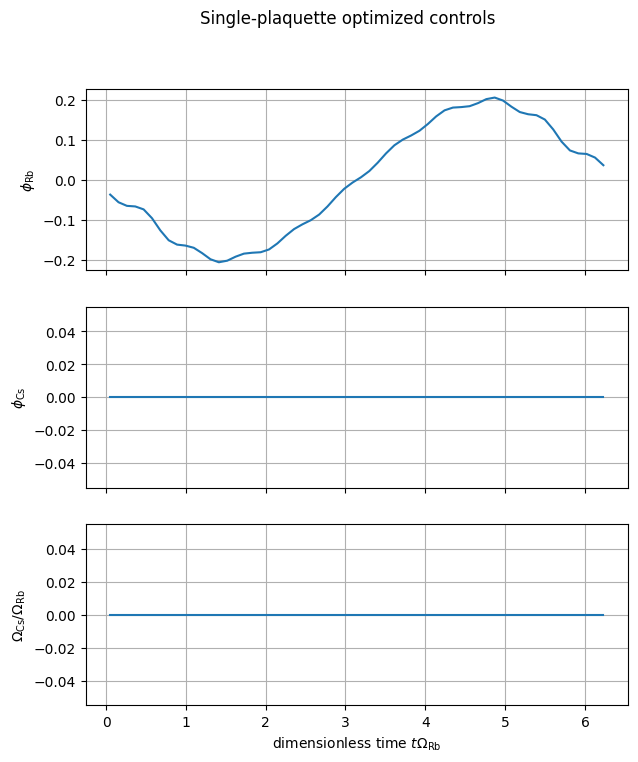

In [69]:
result = locked_result
optimized_controls = layout.unpack(result.parameters)
time_axis = phase_sample_axis(duration=duration, samples=samples)

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
axes[0].plot(time_axis, unwrap_phase_profile(optimized_controls.time_controls["phi_rb"]))
axes[0].set_ylabel(r"$\phi_{\rm Rb}$")
axes[0].grid(True)

axes[1].plot(time_axis, unwrap_phase_profile(optimized_controls.time_controls["phi_cs"]))
axes[1].set_ylabel(r"$\phi_{\rm Cs}$")
axes[1].grid(True)

axes[2].plot(time_axis, optimized_controls.time_controls["ratio_cs"])
axes[2].set_xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
axes[2].set_ylabel(r"$\Omega_{\rm Cs}/\Omega_{\rm Rb}$")
axes[2].grid(True)

fig.suptitle("Single-plaquette optimized controls")
plt.show()

## Population Trace

The cell below traces selected states in the `m4` block. These are not all populations; they are representative basis-state populations for diagnostics.

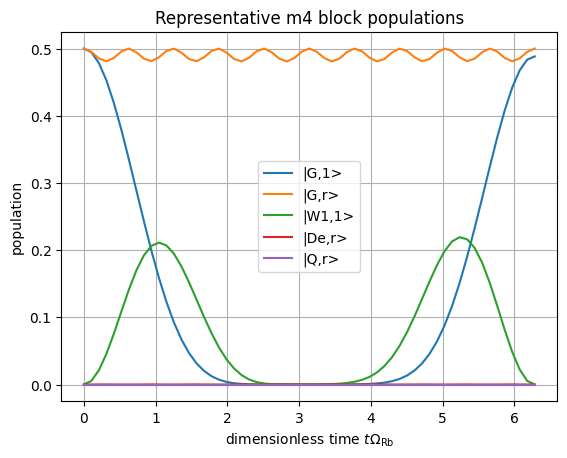

In [66]:
m4_block = next(block for block in problem.blocks if block.name == "m4")
m4_controls = layout.unpack(result.parameters)

population_trace = trace_populations(
    block=m4_block,
    control_values=m4_controls,
    duration=duration,
    samples=samples,
    states={
        "|G,1>": full_basis_state(6, 0, "1"),
        "|G,r>": full_basis_state(6, 0, "r"),
        "|W1,1>": full_basis_state(6, 1, "1"),
        "|De,r>": full_basis_state(6, 2, "r"),
        "|Q,r>": full_basis_state(6, 5, "r"),
    },
)

for label, values in population_trace.populations.items():
    plt.plot(population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel("population")
plt.title("Representative m4 block populations")
plt.legend()
plt.grid(True)
plt.show()

## Optional Time Scan

T*Omega_Rb=8.000, infidelity=7.749397e-09
T*Omega_Rb=7.900, infidelity=9.895794e-09
T*Omega_Rb=7.800, infidelity=7.866154e-09
T*Omega_Rb=7.700, infidelity=3.621033e-09
T*Omega_Rb=7.600, infidelity=1.384617e-10
T*Omega_Rb=7.500, infidelity=7.201930e-10
T*Omega_Rb=7.400, infidelity=6.105780e-09
T*Omega_Rb=7.300, infidelity=9.488873e-09
T*Omega_Rb=7.200, infidelity=6.802155e-09
T*Omega_Rb=7.100, infidelity=4.654083e-09
T*Omega_Rb=7.000, infidelity=5.138343e-10
T*Omega_Rb=6.900, infidelity=2.832339e-09
T*Omega_Rb=6.800, infidelity=5.289928e-09
T*Omega_Rb=6.700, infidelity=9.426250e-09
T*Omega_Rb=6.600, infidelity=9.111998e-09
T*Omega_Rb=6.500, infidelity=4.168600e-09
T*Omega_Rb=6.400, infidelity=1.478282e-10
T*Omega_Rb=6.300, infidelity=2.662961e-09
T*Omega_Rb=6.200, infidelity=1.727839e-03
T*Omega_Rb=6.100, infidelity=8.339582e-03
T*Omega_Rb=6.000, infidelity=1.976663e-02


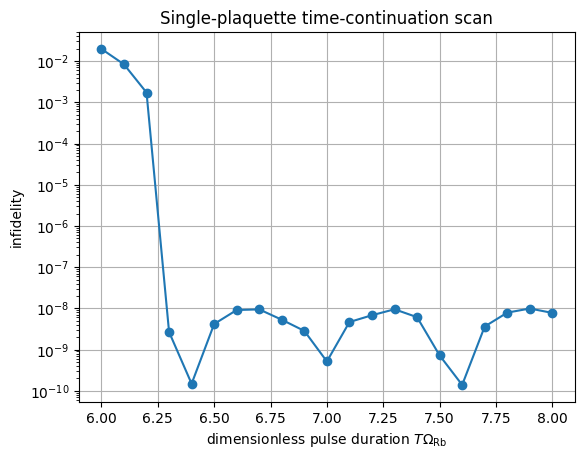

In [53]:
scan_settings = TimeScanSettings(
    start_duration=8.0,
    stop_duration=6.0,
    duration_step=0.1,
    infidelity_threshold=1e-3,
    stop_after_threshold_failure=False,
)
scan_problem = problem.with_duration(scan_settings.start_duration)
scan_points = TimeContinuationScanner(scan_problem, scan_settings).scan_with_locked_parameters(
    initial_parameters=locked_initial_parameters,
    locked_parameter_indices=locked_indices,
)

durations = np.array([point.duration for point in scan_points], dtype=np.float64)
infidelities = np.array([point.result.infidelity for point in scan_points], dtype=np.float64)
order = np.argsort(durations)

for duration_value, infidelity_value in zip(durations, infidelities, strict=True):
    print(f"T*Omega_Rb={duration_value:.3f}, infidelity={infidelity_value:.6e}")

plt.semilogy(durations[order], infidelities[order], marker="o")
plt.xlabel(r"dimensionless pulse duration $T\Omega_{\rm Rb}$")
plt.ylabel("infidelity")
plt.title("Single-plaquette time-continuation scan")
plt.grid(True)
plt.show()

## Last Scan Point Diagnostics

The cells below inspect the final point returned by the continuation scan. This is usually the shortest successful duration, or the first duration that crosses the configured infidelity threshold when `stop_after_threshold_failure=True`.

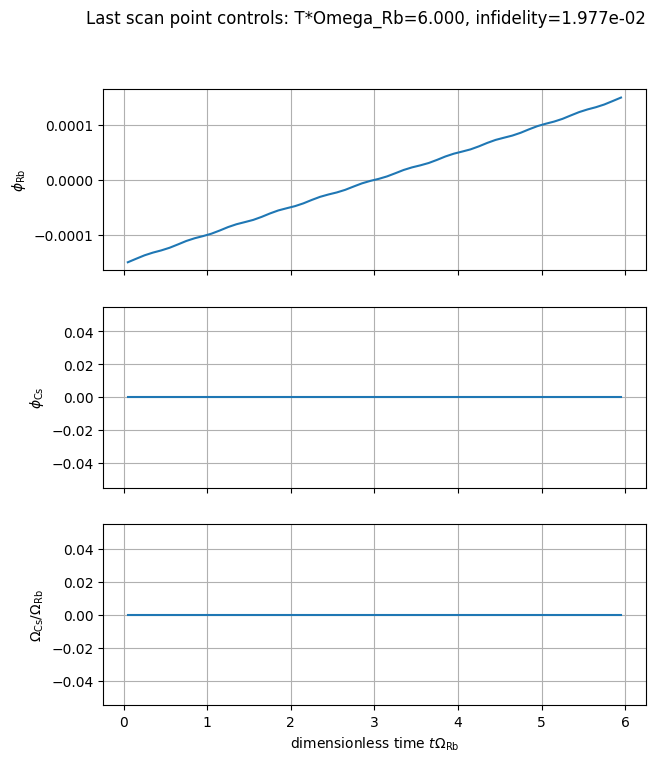

In [54]:
last_scan_point = scan_points[-1]
last_scan_controls = layout.unpack(last_scan_point.result.parameters)
last_scan_time_axis = phase_sample_axis(duration=last_scan_point.duration, samples=samples)

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
axes[0].plot(last_scan_time_axis, unwrap_phase_profile(last_scan_controls.time_controls["phi_rb"]))
axes[0].set_ylabel(r"$\phi_{\rm Rb}$")
axes[0].grid(True)

axes[1].plot(last_scan_time_axis, unwrap_phase_profile(last_scan_controls.time_controls["phi_cs"]))
axes[1].set_ylabel(r"$\phi_{\rm Cs}$")
axes[1].grid(True)

axes[2].plot(last_scan_time_axis, last_scan_controls.time_controls["ratio_cs"])
axes[2].set_xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
axes[2].set_ylabel(r"$\Omega_{\rm Cs}/\Omega_{\rm Rb}$")
axes[2].grid(True)

fig.suptitle(
    f"Last scan point controls: "
    f"T*Omega_Rb={last_scan_point.duration:.3f}, "
    f"infidelity={last_scan_point.result.infidelity:.3e}"
)
plt.show()

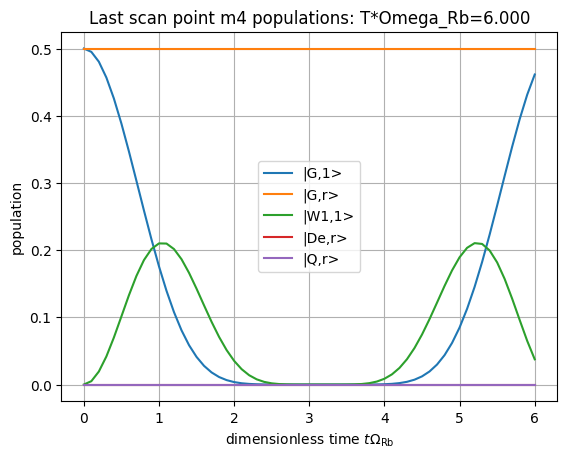

In [55]:
last_scan_m4_block = next(block for block in problem.blocks if block.name == "m4")
last_scan_population_trace = trace_populations(
    block=last_scan_m4_block,
    control_values=last_scan_controls,
    duration=last_scan_point.duration,
    samples=samples,
    states={
        "|G,1>": full_basis_state(6, 0, "1"),
        "|G,r>": full_basis_state(6, 0, "r"),
        "|W1,1>": full_basis_state(6, 1, "1"),
        "|De,r>": full_basis_state(6, 2, "r"),
        "|Q,r>": full_basis_state(6, 5, "r"),
    },
)

for label, values in last_scan_population_trace.populations.items():
    plt.plot(last_scan_population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel("population")
plt.title(
    f"Last scan point m4 populations: "
    f"T*Omega_Rb={last_scan_point.duration:.3f}"
)
plt.legend()
plt.grid(True)
plt.show()